In [1]:
# import os
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"

In [59]:
import numpy as np
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping
import uproot
from scipy.stats import norm
import awkward as ak
from utils.data_utils import *

In [60]:
# Load pseudodata file
f_pd = uproot.open("/global/cfs/cdirs/m3246/ZjetOmnifold/data/slimmed_files_v3/Pseudodata_WithSherapaNoReweighting_12May2025_topLogit.root")
t_pd = f_pd["OmniTree"]

# Load pass 190 and isTop flags
pass190_pd = ak.to_numpy(t_pd["pass190"].array())

# Load PD kinematics, dropping top evets
print(f"pd events: {np.sum(pass190_pd)}")
print("We have a fraction {} of good events in pseudodata".format(np.sum(pass190_pd) / len(pass190_pd)))
pd_kinematics, pd_ind = get_kinematics(t_pd, muon_only=False)

pd events: 233729
We have a fraction 1.0 of good events in pseudodata


In [61]:
# Load top MC files
f_top = uproot.open("/global/cfs/cdirs/m3246/ZjetOmnifold/data/slimmed_files_v3/ZjetOmnifold_14May2025_Background_Sherpa2212_AllTop_WithTracks_slim_Systematics_topLogit.root")
t_top = f_top["OmniTree"]
# Load Top kinematics
pass190_top = ak.to_numpy(t_top['pass190'].array())
print(f"top events: {np.sum(pass190_top)}")
print("We have a fracion {} of good events in top".format(np.sum(pass190_top) / len(pass190_top)))
top_kinematics, top_ind = get_kinematics(t_top, muon_only=False)

top events: 21017
We have a fracion 0.9988593698018156 of good events in top


In [62]:
# Get initial weights
w_top = get_observables(t_top, ["weight"])
w_pd = get_observables(t_pd, ["weight"])

In [63]:
## the istop logit tells us how Top-like is a given event
istop_pd = get_observables(t_pd, ["isTop_logit"])
istop_top = get_observables(t_top, ["isTop_logit"])

In [64]:
x_pd = istop_pd
x_top = istop_top

In [140]:
def reweight(model, events):
    f = model.predict(events, batch_size=10000)
    weights = f / (1. - f) #for binary cross entropy - see refs. above and https://arxiv.org/abs/2101.07263 for more info.
    return np.squeeze(np.nan_to_num(weights)) 

## Train a simple NN with Top 1xsub

In [148]:
x_data_and_MCback = np.concatenate([x_top,x_pd, x_pd])
y_data_and_MCback = np.concatenate([np.ones(len(x_top)), np.ones(len(x_pd)),np.zeros(len(x_pd))])
w_data_and_MCback_1xsub = np.concatenate([-1*w_top, w_pd, w_pd])

In [149]:
X_train_1_1xsub, X_test_1_1xsub, Y_train_1_1xsub, Y_test_1_1xsub, w_train_1_1xsub, w_test_1_1xsub = train_test_split(
    x_data_and_MCback, y_data_and_MCback, w_data_and_MCback_1xsub)

In [150]:
inputs = Input((1, ))
hidden_layer_1 = Dense(50, activation='relu')(inputs)
hidden_layer_2 = Dense(50, activation='relu')(hidden_layer_1)
hidden_layer_3 = Dense(50, activation='relu')(hidden_layer_2)
outputs = Dense(1, activation='sigmoid')(hidden_layer_3)

model = Model(inputs=inputs, outputs=outputs)

In [151]:
earlystopping = EarlyStopping(patience=10,
                              verbose=1,
                              restore_best_weights=True)
    
model.compile(loss='binary_crossentropy',
              optimizer='Adam',
              metrics=['accuracy'],
              weighted_metrics=[]) #to silence an annoying warning ... could compute the weighted accuracy
model.fit(X_train_1_1xsub,
          Y_train_1_1xsub,
          sample_weight=w_train_1_1xsub,
          epochs=200,
          batch_size=10000,
          validation_data=(X_test_1_1xsub, Y_test_1_1xsub, w_test_1_1xsub),
          callbacks=[earlystopping],
          verbose=0)

Epoch 16: early stopping
Restoring model weights from the end of the best epoch: 6.


In [152]:
w_data_1xsub = reweight(model,x_pd)

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


Mean of the derived PD weights for 1xsub NN: 0.9889084100723267


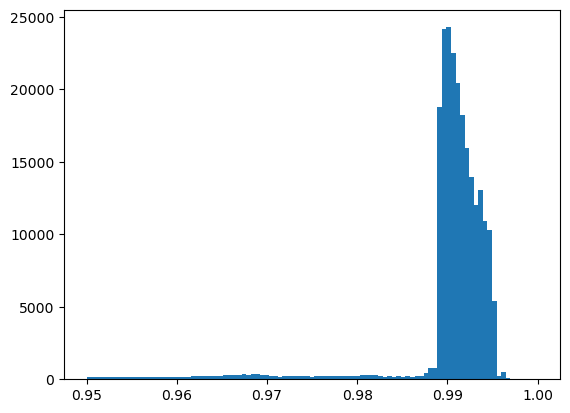

In [153]:
plt.hist(w_data_1xsub, bins=np.linspace(0.95, 1, 100))
print(f"Mean of the derived PD weights for 1xsub NN: {np.mean(w_data_1xsub)}")

## Train NN  with -10*Top weights

In [165]:
w_data_and_MCback_10xsub = np.concatenate([-10*w_top, w_pd, w_pd])

In [166]:
X_train_1_10xsub, X_test_1_10xsub, Y_train_1_10xsub, Y_test_1_10xsub, w_train_1_10xsub, w_test_1_10xsub = train_test_split(
    x_data_and_MCback, y_data_and_MCback, w_data_and_MCback_10xsub)

In [167]:
inputs = Input((1, ))
hidden_layer_1 = Dense(50, activation='relu')(inputs)
hidden_layer_2 = Dense(50, activation='relu')(hidden_layer_1)
hidden_layer_3 = Dense(50, activation='relu')(hidden_layer_2)
outputs = Dense(1, activation='sigmoid')(hidden_layer_3)

model_10xsub = Model(inputs=inputs, outputs=outputs)

In [168]:
earlystopping = EarlyStopping(patience=10,
                              verbose=1,
                              restore_best_weights=True)
    
model_10xsub.compile(loss='binary_crossentropy',
              optimizer='Adam',
              metrics=['accuracy'],
              weighted_metrics=[]) #to silence an annoying warning ... could compute the weighted accuracy
model_10xsub.fit(X_train_1_10xsub,
          Y_train_1_10xsub,
          sample_weight=w_train_1_10xsub,
          epochs=200,
          batch_size=10000,
          validation_data=(X_test_1_10xsub, Y_test_1_10xsub, w_test_1_10xsub),
          callbacks=[earlystopping],
          verbose=0)

Epoch 19: early stopping
Restoring model weights from the end of the best epoch: 9.


In [176]:
w_data_10xsub = reweight(model_10xsub,x_pd)
print(f"Mean of the derived PD weights for 10xsub NN: {np.mean(w_data_10xsub)}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 
Mean of the derived PD weights for 10xsub NN: 0.978137731552124


## Train NN  with 9*Top weights

In [179]:
x_data_and_MCback_9xadd = np.concatenate([x_top,x_pd])
y_data_and_MCback_9xadd = np.concatenate([np.ones(len(x_top)),np.zeros(len(x_pd))])
w_data_and_MCback_9xadd = np.concatenate([9*w_top, w_pd])

In [180]:
X_train_1_9xadd, X_test_1_9xadd, Y_train_1_9xadd, Y_test_1_9xadd, w_train_1_9xadd, w_test_1_9xadd = train_test_split(
    x_data_and_MCback_9xadd, y_data_and_MCback_9xadd, w_data_and_MCback_9xadd)

In [181]:
inputs = Input((1, ))
hidden_layer_1 = Dense(50, activation='relu')(inputs)
hidden_layer_2 = Dense(50, activation='relu')(hidden_layer_1)
hidden_layer_3 = Dense(50, activation='relu')(hidden_layer_2)
outputs = Dense(1, activation='sigmoid')(hidden_layer_3)

model_9xadd = Model(inputs=inputs, outputs=outputs)

In [182]:
earlystopping = EarlyStopping(patience=10,
                              verbose=1,
                              restore_best_weights=True)
    
model_9xadd.compile(loss='binary_crossentropy',
              optimizer='Adam',
              metrics=['accuracy'],
              weighted_metrics=[]) #to silence an annoying warning ... could compute the weighted accuracy
model_9xadd.fit(X_train_1_9xadd,
          Y_train_1_9xadd,
          sample_weight=w_train_1_9xadd,
          epochs=200,
          batch_size=10000,
          validation_data=(X_test_1_9xadd, Y_test_1_9xadd, w_test_1_9xadd),
          callbacks=[earlystopping],
          verbose=0)

Epoch 56: early stopping
Restoring model weights from the end of the best epoch: 46.


In [183]:
w_data_9xadd = reweight(model_9xadd, x_pd)
print(f"Mean of the derived PD weights for 9xadd NN: {np.mean(w_data_9xadd)}")

24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
Mean of the derived PD weights for 9xadd NN: 0.01996139995753765


In [257]:
w_data_final = w_data_10xsub + w_data_9xadd
print(f"{np.mean(w_data_final)}")

0.998099148273468


(array([3.1000e+02, 2.9800e+02, 2.6700e+02, 2.4500e+02, 2.3600e+02,
        2.2400e+02, 2.1500e+02, 1.4800e+02, 1.9600e+02, 1.8200e+02,
        1.6000e+02, 1.7000e+02, 1.8300e+02, 1.4600e+02, 1.8000e+02,
        1.5300e+02, 1.4100e+02, 1.5100e+02, 1.6000e+02, 1.4100e+02,
        1.4400e+02, 1.4800e+02, 1.2500e+02, 1.3400e+02, 1.3000e+02,
        1.4500e+02, 1.3900e+02, 1.3300e+02, 1.1800e+02, 1.1900e+02,
        1.2800e+02, 1.2500e+02, 1.3500e+02, 1.1800e+02, 1.6800e+02,
        1.7400e+02, 1.5800e+02, 1.7800e+02, 1.3400e+02, 1.8200e+02,
        1.7400e+02, 1.8400e+02, 2.2900e+02, 1.2510e+03, 1.3300e+03,
        1.0060e+03, 9.4100e+02, 9.6300e+02, 7.4665e+04, 5.3906e+04,
        5.6576e+04, 2.0126e+04, 2.6580e+03, 3.2890e+03, 2.0290e+03,
        1.1470e+03, 1.8490e+03, 1.8670e+03, 9.0000e+00, 9.0000e+00,
        7.0000e+00, 8.0000e+00, 1.1000e+01, 4.0000e+00, 4.0000e+00,
        1.2000e+01, 1.2000e+01, 8.0000e+00, 8.0000e+00, 1.0000e+00,
        7.0000e+00, 1.1000e+01, 7.0000e+00, 9.00

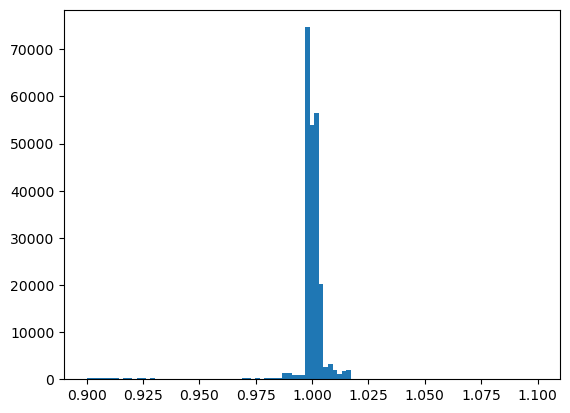

In [258]:
plt.hist(w_data_final, bins=np.linspace(0.9,1.1, 100))
# plt.yscale("log")

# Let's see what the different reweightings look like

In [185]:
pd_m1_pt = np.exp(pd_kinematics[:, 0, 0])
top_m1_pt = np.exp(top_kinematics[:, 0, 0])

pd_m2_pt = np.exp(pd_kinematics[:, 0, 1])
top_m2_pt = np.exp(top_kinematics[:, 0, 1])

In [186]:
bins=np.linspace(0, 1000, 30)
h_pd, _ = np.histogram(pd_m1_pt, bins=bins, density=False)
h_pd_1xsub, _ = np.histogram(pd_m1_pt, weights=w_data_1xsub.flatten(), bins=bins, density=False)
h_pd_10xsub, _ = np.histogram(pd_m1_pt, weights=w_data_10xsub.flatten(), bins=bins, density=False)
h_pd_final, _ = np.histogram(pd_m1_pt, weights=w_data_final.flatten(), bins=bins, density=False)

residual_1xsub = h_pd - h_pd_1xsub
residual_10xsub = h_pd - h_pd_10xsub
residual_final = h_pd - h_pd_final

bin_centers = (bins[:-1] + bins[1:]) / 2

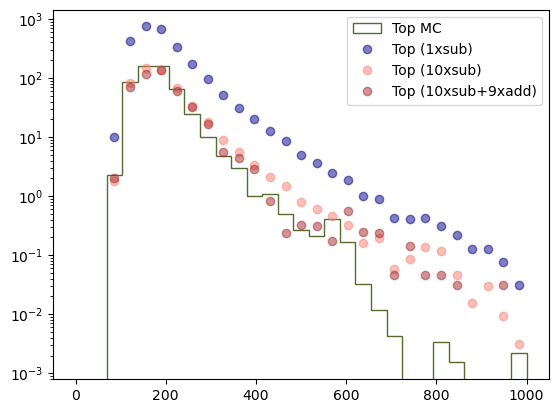

In [192]:
plt.hist(top_m1_pt, bins=bins, weights=w_top.flatten(), density=False, histtype="step", color="darkolivegreen", label="Top MC")

plt.plot(bin_centers, residual_1xsub, alpha=0.5, marker="o", linestyle="none", color="darkblue", label='Top (1xsub)')
plt.plot(bin_centers, residual_10xsub/10, alpha=0.5, marker="o", linestyle="none", color="salmon", label='Top (10xsub)')
plt.plot(bin_centers, residual_final, alpha=0.5, marker="o", linestyle="none", color="brown", label='Top (10xsub+9xadd)')
plt.legend()
plt.yscale("log")

In [238]:
def mkplot(pd_var, top_var, pd_weight_10xsub, pd_weight_1xsub, pd_weight_add, top_weight, bins, xlabel):
    # Calculate histograms
    hist_pd,_ = np.histogram(pd_var, bins=bins, density=False)
    hist_pd_reweighted_10xsub,_ = np.histogram(pd_var, weights=pd_weight_10xsub.flatten(), bins=bins, density=False)
    hist_pd_reweighted_1xsub,_ = np.histogram(pd_var, weights=pd_weight_1xsub.flatten(), bins=bins, density=False)
    hist_pd_reweighted_add,_ = np.histogram(pd_var, weights=pd_weight_add.flatten(), bins=bins, density=False)
    
    residual_pd_10xsub = np.array(hist_pd - hist_pd_reweighted_10xsub)
    residual_pd_1xsub = np.array(hist_pd - hist_pd_reweighted_1xsub)
    residual_pd_add = np.array(hist_pd - hist_pd_reweighted_add)
    
    hist_top,_ = np.histogram(top_var, bins=bins, weights=top_weight.flatten(), density=False)
    hist_top = np.array(hist_top)

    # print(hist_pd)
    # print(hist_pd_reweighted)
    # print(residual_pd)
    bin_centers = (bins[:-1] + bins[1:]) / 2
    
    # Create subplots
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), 
                                   gridspec_kw={'height_ratios': [3, 1], 'hspace': 0.05})
    # fig, (ax1) = plt.subplots(1, 1, figsize=(10, 8))
    # Main plot
    ax1.hist(pd_var, bins=bins, density=False, histtype="step", label="PD w. Top contrib")
    ax1.hist(pd_var, bins=bins, weights=pd_weight_1xsub, density=False, histtype="step", color="darkblue",label="PD - Top (1xsub)")
    ax1.hist(pd_var, bins=bins, weights=pd_weight_10xsub, density=False, histtype="step", color="salmon",label="PD - Top (10xsub)")
    ax1.hist(pd_var, bins=bins, weights=pd_weight_add, density=False, histtype="step", color="brown",label="PD - Top (10xsub+9xadd)")
    
    ax1.hist(top_var, bins=bins, weights=top_weight.flatten(), density=False, histtype="step", color="darkolivegreen", label="Top MC")

    ax1.plot(bin_centers, residual_pd_1xsub, alpha=0.5, marker="o", linestyle="none", color="darkblue", label='Top (1xsub)')
    ax1.plot(bin_centers, residual_pd_10xsub/10, alpha=0.5, marker="o", linestyle="none", color="salmon", label='Top (10xsub)')
    ax1.plot(bin_centers, residual_pd_add, alpha=0.5, marker="o", linestyle="none", color="brown", label='Top (10xsub+9xadd)')
    
    ax1.set_ylabel("Number of events")
    ax1.set_yscale("log")
    ax1.legend()
    ax1.tick_params(axis='x', labelbottom=False)  # Hide x-axis labels on top plot
    
    # Ratio plot
    # Calculate ratio: Top / Top subtracted PD
    # Handle division by zero and negative values
    ratio_1xsub = np.divide(hist_top, residual_pd_1xsub, out=np.zeros_like(hist_top), where=(residual_pd_1xsub != 0))
    ratio_10xsub = np.divide(hist_top, residual_pd_10xsub/10, out=np.zeros_like(hist_top), where=(residual_pd_10xsub != 0))
    ratio_add = np.divide(hist_top, residual_pd_add, out=np.zeros_like(hist_top), where=(residual_pd_add != 0))

    print(len(ratio_1xsub))
    
    # Only plot points where both values are positive
    valid_mask = (hist_top > 0) & (residual_pd_1xsub > 0)
    
    ax2.plot(bin_centers[valid_mask], ratio_1xsub[valid_mask], 'ko-', markersize=4, linewidth=1, color="darkblue")
    ax2.plot(bin_centers[valid_mask], ratio_10xsub[valid_mask], 'ko-', markersize=4, linewidth=1, color="salmon")
    ax2.plot(bin_centers[valid_mask], ratio_add[valid_mask], 'ko-', markersize=4, linewidth=1, color="brown")

    ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.7)
    ax2.set_xlabel(xlabel)
    ax2.set_ylabel("Top MC/ Top from NN")
    ax2.grid(True, alpha=0.3)
    
    # Set reasonable y-limits for ratio plot
    # if np.any(valid_mask):
    #     valid_ratios = ratio_1xsub[valid_mask]
    #     y_min = max(0.1, np.min(valid_ratios) * 0.9)
    #     y_max = min(10, np.max(valid_ratios) * 1.1)
    ax2.set_ylim(0, 1.5)
    
    plt.tight_layout()
    # return fig, (ax1)
    
    return fig, (ax1, ax2)

29


/tmp/ipykernel_484781/1919853509.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko-" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(bin_centers[valid_mask], ratio_1xsub[valid_mask], 'ko-', markersize=4, linewidth=1, color="darkblue")
/tmp/ipykernel_484781/1919853509.py:54: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko-" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(bin_centers[valid_mask], ratio_10xsub[valid_mask], 'ko-', markersize=4, linewidth=1, color="salmon")
/tmp/ipykernel_484781/1919853509.py:55: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko-" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(bin_centers[valid_mask], ratio_add[valid_mask], 'ko-', markersize=4, linewidth=1, color="brown")
/tmp/ipykernel_484781/1919853509.py:69: UserWarning: This figure includes

(<Figure size 1000x800 with 2 Axes>,
 (<Axes: ylabel='Number of events'>,
  <Axes: xlabel='Muon 1 pT [GeV]', ylabel='Top MC/ Top from NN'>))

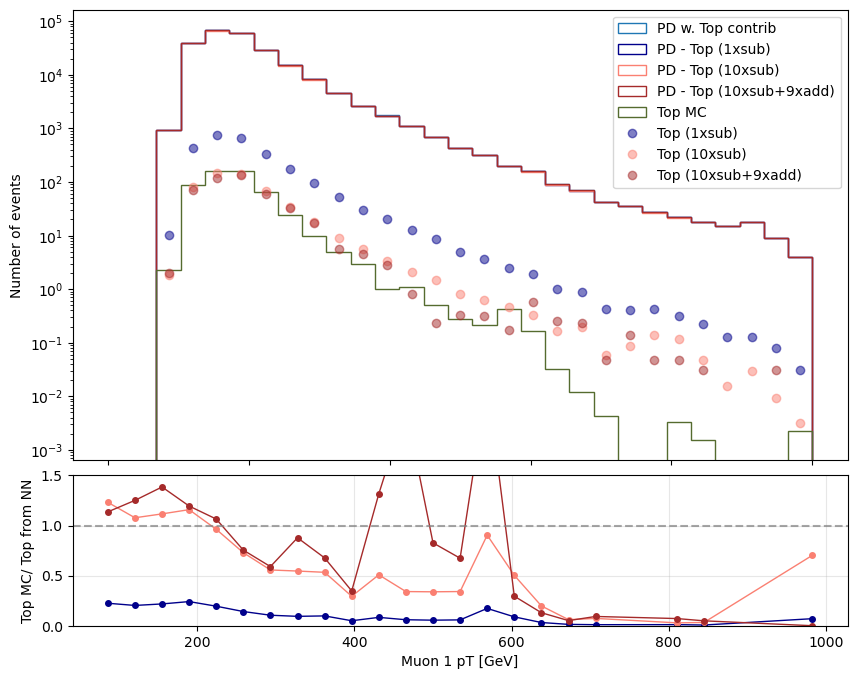

In [239]:
mkplot(pd_m1_pt, top_m1_pt, w_data_10xsub, w_data_1xsub, w_data_final, w_top, np.linspace(0, 1000, 30), "Muon 1 pT [GeV]")

29


/tmp/ipykernel_484781/1919853509.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko-" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(bin_centers[valid_mask], ratio_1xsub[valid_mask], 'ko-', markersize=4, linewidth=1, color="darkblue")
/tmp/ipykernel_484781/1919853509.py:54: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko-" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(bin_centers[valid_mask], ratio_10xsub[valid_mask], 'ko-', markersize=4, linewidth=1, color="salmon")
/tmp/ipykernel_484781/1919853509.py:55: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko-" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(bin_centers[valid_mask], ratio_add[valid_mask], 'ko-', markersize=4, linewidth=1, color="brown")
/tmp/ipykernel_484781/1919853509.py:69: UserWarning: This figure includes

(<Figure size 1000x800 with 2 Axes>,
 (<Axes: ylabel='Number of events'>,
  <Axes: xlabel='Muon 2 pT [GeV]', ylabel='Top MC/ Top from NN'>))

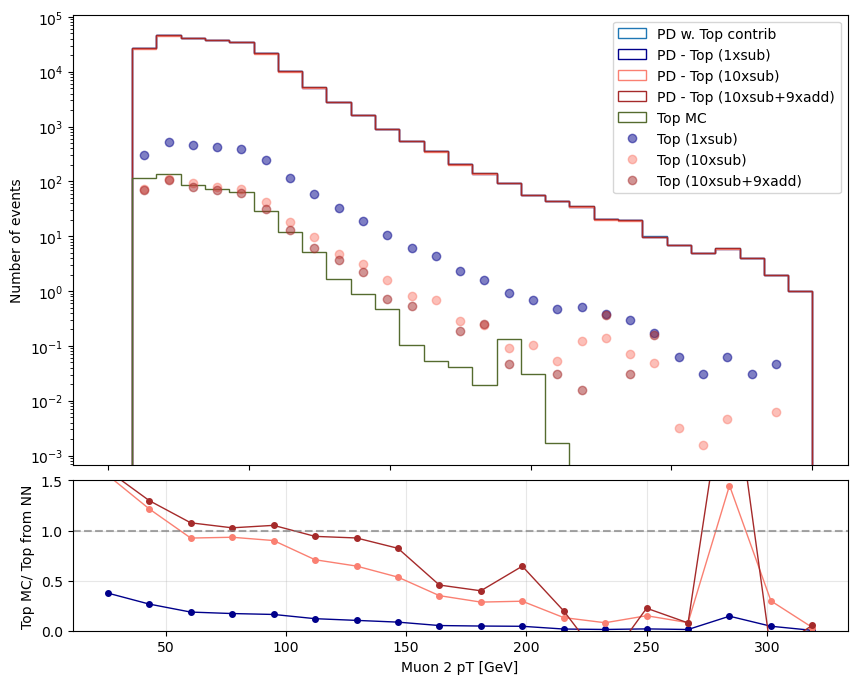

In [240]:
mkplot(pd_m2_pt, top_m2_pt, w_data_10xsub, w_data_1xsub, w_data_final, w_top, np.linspace(0, 500, 30), "Muon 2 pT [GeV]")

In [241]:
pd_m1_eta = pd_kinematics[:, 1, 0]
pd_m2_eta = pd_kinematics[:, 1, 1]
pd_m1_phi = pd_kinematics[:, 2, 0]
pd_m2_phi = pd_kinematics[:, 2, 1]

top_m1_eta = top_kinematics[:, 1, 0]
top_m2_eta = top_kinematics[:, 1, 1]
top_m1_phi = top_kinematics[:, 2, 0]
top_m2_phi = top_kinematics[:, 2, 1]

29


/tmp/ipykernel_484781/1919853509.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko-" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(bin_centers[valid_mask], ratio_1xsub[valid_mask], 'ko-', markersize=4, linewidth=1, color="darkblue")
/tmp/ipykernel_484781/1919853509.py:54: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko-" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(bin_centers[valid_mask], ratio_10xsub[valid_mask], 'ko-', markersize=4, linewidth=1, color="salmon")
/tmp/ipykernel_484781/1919853509.py:55: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko-" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(bin_centers[valid_mask], ratio_add[valid_mask], 'ko-', markersize=4, linewidth=1, color="brown")
/tmp/ipykernel_484781/1919853509.py:69: UserWarning: This figure includes

(<Figure size 1000x800 with 2 Axes>,
 (<Axes: ylabel='Number of events'>,
  <Axes: xlabel='Muon 1 eta', ylabel='Top MC/ Top from NN'>))

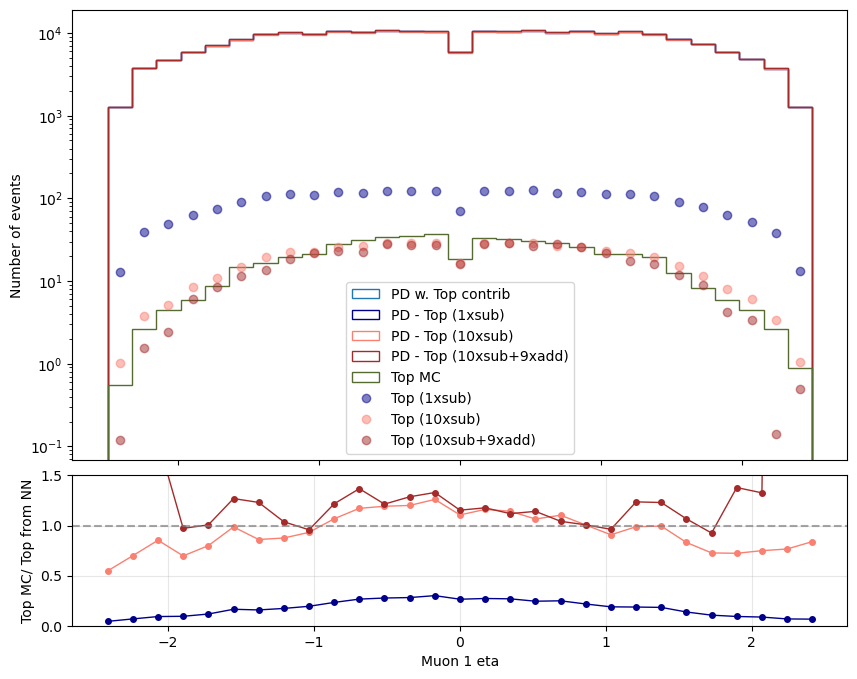

In [242]:
mkplot(pd_m1_eta, top_m1_eta, w_data_10xsub, w_data_1xsub, w_data_final, w_top, np.linspace(-2.5, 2.5, 30), "Muon 1 eta")

29


/tmp/ipykernel_484781/1919853509.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko-" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(bin_centers[valid_mask], ratio_1xsub[valid_mask], 'ko-', markersize=4, linewidth=1, color="darkblue")
/tmp/ipykernel_484781/1919853509.py:54: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko-" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(bin_centers[valid_mask], ratio_10xsub[valid_mask], 'ko-', markersize=4, linewidth=1, color="salmon")
/tmp/ipykernel_484781/1919853509.py:55: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko-" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(bin_centers[valid_mask], ratio_add[valid_mask], 'ko-', markersize=4, linewidth=1, color="brown")
/tmp/ipykernel_484781/1919853509.py:69: UserWarning: This figure includes

(<Figure size 1000x800 with 2 Axes>,
 (<Axes: ylabel='Number of events'>,
  <Axes: xlabel='Muon 2 eta', ylabel='Top MC/ Top from NN'>))

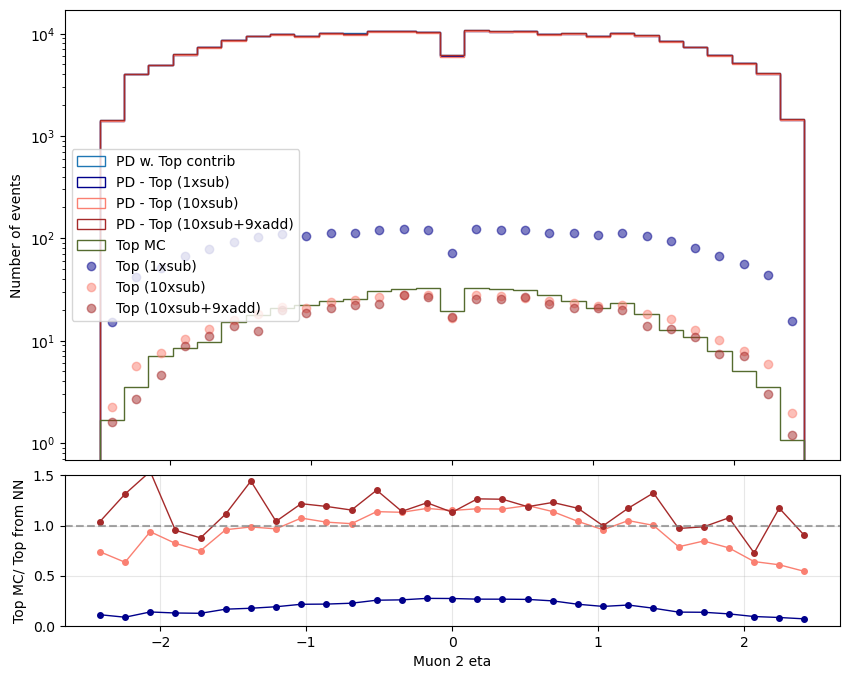

In [243]:
mkplot(pd_m2_eta, top_m2_eta, w_data_10xsub, w_data_1xsub, w_data_final, w_top, np.linspace(-2.5, 2.5, 30), "Muon 2 eta")

In [247]:
top_v1 = np.stack([top_m1_pt * np.cos(top_m1_phi), top_m1_pt * np.sin(top_m1_phi), top_m1_pt * np.sinh(top_m1_eta)], axis=1)
top_v2 = np.stack([top_m2_pt * np.cos(top_m2_phi), top_m2_pt * np.sin(top_m2_phi), top_m2_pt * np.sinh(top_m2_eta)], axis=1)
top_vall = top_v1 + top_v2

top_mm_pt = np.sqrt(top_vall[:,0]**2 + top_vall[:,1]**2)

In [248]:
pd_v1 = np.stack([pd_m1_pt * np.cos(pd_m1_phi), pd_m1_pt * np.sin(pd_m1_phi), pd_m1_pt * np.sinh(pd_m1_eta)], axis=1)
pd_v2 = np.stack([pd_m2_pt * np.cos(pd_m2_phi), pd_m2_pt * np.sin(pd_m2_phi), pd_m2_pt * np.sinh(pd_m2_eta)], axis=1)
pd_vall = pd_v1 + pd_v2

pd_mm_pt = np.sqrt(pd_vall[:,0]**2 + pd_vall[:,1]**2)

29


/tmp/ipykernel_484781/1919853509.py:53: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko-" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(bin_centers[valid_mask], ratio_1xsub[valid_mask], 'ko-', markersize=4, linewidth=1, color="darkblue")
/tmp/ipykernel_484781/1919853509.py:54: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko-" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(bin_centers[valid_mask], ratio_10xsub[valid_mask], 'ko-', markersize=4, linewidth=1, color="salmon")
/tmp/ipykernel_484781/1919853509.py:55: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "ko-" (-> color='k'). The keyword argument will take precedence.
  ax2.plot(bin_centers[valid_mask], ratio_add[valid_mask], 'ko-', markersize=4, linewidth=1, color="brown")
/tmp/ipykernel_484781/1919853509.py:69: UserWarning: This figure includes

(<Figure size 1000x800 with 2 Axes>,
 (<Axes: ylabel='Number of events'>,
  <Axes: xlabel='Di-Muon pT [GeV]', ylabel='Top MC/ Top from NN'>))

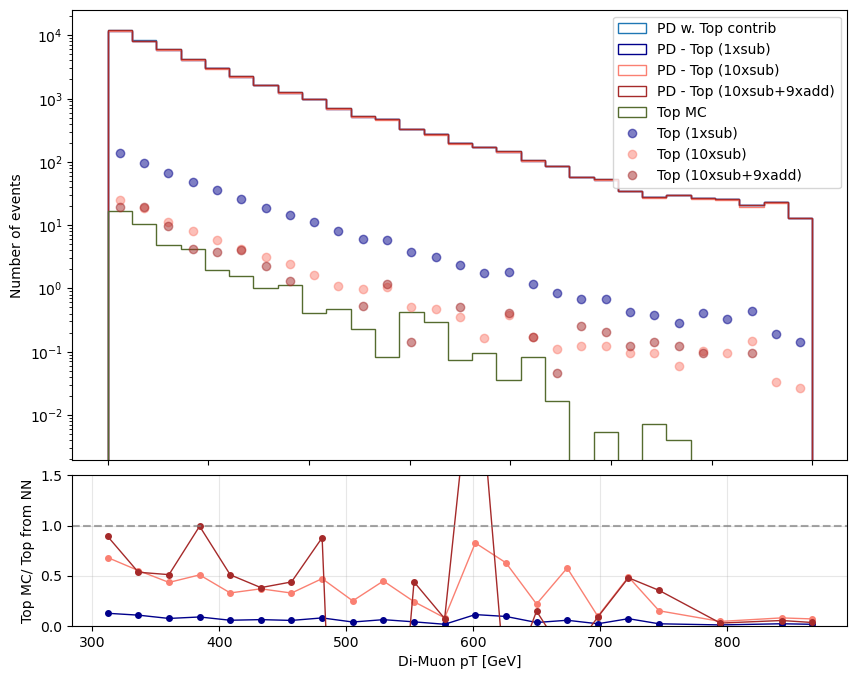

In [249]:
mkplot(pd_mm_pt, top_mm_pt, w_data_10xsub, w_data_1xsub, w_data_final, w_top, np.linspace(300, 1000, 30), "Di-Muon pT [GeV]")